In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'projectAutono', 'textmining', 'projectmining', 'projectNLP']


In [4]:
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'projectAutono', 'textmining', 'projectmining', 'projectNLP']


In [5]:
import os

path = "/content/drive/MyDrive/projectNLP"
print(os.listdir(path))

['archive (1).zip']


In [7]:
import zipfile
import os

path = "/content/drive/MyDrive/projectNLP"

zip_path = path + "/archive (1).zip"
extract_path = path + "/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Done extracting!")

✅ Done extracting!


In [8]:
print(os.listdir("/content/drive/MyDrive/projectNLP/data"))

['IMDB Dataset.csv']


In [9]:
import pandas as pd

file_path = "/content/drive/MyDrive/projectNLP/data/IMDB Dataset.csv"

df = pd.read_csv(file_path)

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [10]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [11]:
import re

def clean_text(text):
    text = text.lower()  # تصغير الحروف
    text = re.sub(r'<br />', ' ', text)  # إزالة HTML
    text = re.sub(r'[^a-zA-Z ]', '', text)  # إزالة الرموز
    return text

df['review'] = df['review'].apply(clean_text)

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [13]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])

In [14]:
X = pad_sequences(sequences, maxlen=200)
y = df['sentiment'].values

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [17]:
model = Sequential()

# طبقة تحويل الكلمات إلى تمثيل رقمي
model.add(Embedding(input_dim=10000, output_dim=128))

# LSTM layer (تفهم تسلسل الكلمات)
model.add(LSTM(128, return_sequences=False))

# تقليل overfitting
model.add(Dropout(0.5))

# طبقة التصنيف
model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 240s 382ms/step - accuracy: 0.8196 - loss: 0.3971 - val_accuracy: 0.8759 - val_loss: 0.3024
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 385ms/step - accuracy: 0.9002 - loss: 0.2593 - val_accuracy: 0.8876 - val_loss: 0.2838
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 262s 419ms/step - accuracy: 0.9194 - loss: 0.2097 - val_accuracy: 0.8829 - val_loss: 0.2935
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 418ms/step - accuracy: 0.9369 - loss: 0.1721 - val_accuracy: 0.8775 - val_loss: 0.3287
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 374ms/step - accuracy: 0.9502 - loss: 0.1356 - val_accuracy: 0.8811 - val_loss: 0.3503


In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.8811 - loss: 0.3503
Test Accuracy: 0.8810999989509583


In [21]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=200)

    pred = model.predict(padded)[0][0]

    if pred > 0.5:
        return "Positive 👍"
    else:
        return "Negative 👎"

In [22]:
print(predict_sentiment("This movie was amazing and very interesting"))
print(predict_sentiment("This movie was boring and bad"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Negative 👎
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Negative 👎


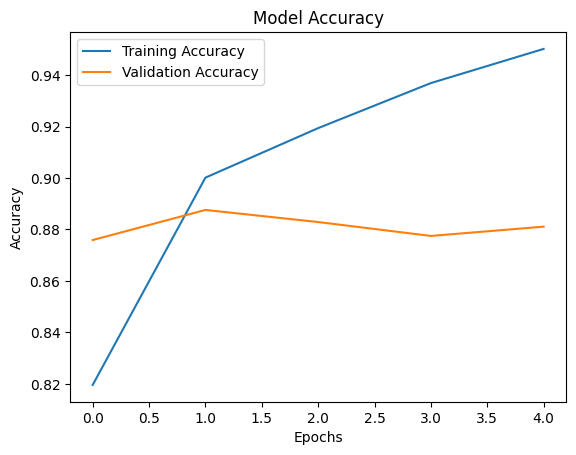

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [24]:
plt.savefig("accuracy_graph.png")

<Figure size 640x480 with 0 Axes>